In [1]:
import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn

print(torch.__version__)
print(torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

model = maskrcnn_resnet50_fpn(weights="DEFAULT")
model = model.cuda()
model.eval()

print("✅ Torchvision Mask R-CNN OK")


2.8.0+cu126
0.23.0+cu126
CUDA: True
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 219MB/s] 


✅ Torchvision Mask R-CNN OK


In [2]:
import torch
from torch.utils.data import Dataset
import numpy as np
import cv2
import os


XỬ LÝ ẢNH SAR

In [3]:
DATA_ROOT = "/kaggle/input/processed-data/processed_mmrotate_data"
import os

print("Train images:", len(os.listdir(f"{DATA_ROOT}/train/images")))
print("Train labels:", len(os.listdir(f"{DATA_ROOT}/train/labelTxt")))

print("Val images:", len(os.listdir(f"{DATA_ROOT}/val/images")))
print("Val labels:", len(os.listdir(f"{DATA_ROOT}/val/labelTxt")))


Train images: 12988
Train labels: 12988
Val images: 695
Val labels: 695


Load

Image shape: (1024, 1024)


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

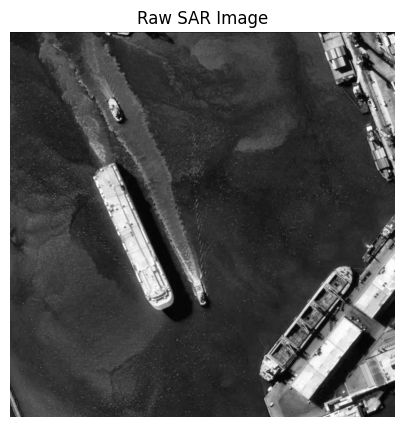

In [4]:
import cv2
import matplotlib.pyplot as plt

img_name = os.listdir(f"{DATA_ROOT}/train/images")[0]
img_path = f"{DATA_ROOT}/train/images/{img_name}"

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

print("Image shape:", img.shape)

plt.figure(figsize=(5,5))
plt.imshow(img, cmap="gray")
plt.title("Raw SAR Image")
plt.axis("off")


Test

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

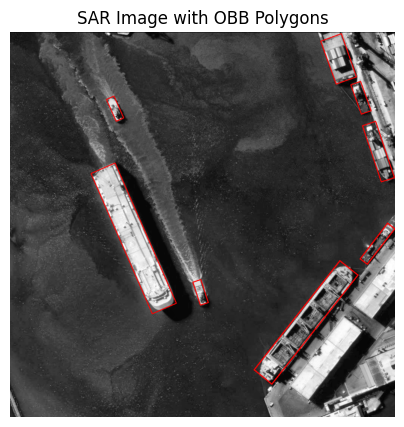

In [5]:
import numpy as np

def read_mmrotate_label(label_path):
    polygons = []
    with open(label_path, "r") as f:
        for line in f:
            vals = line.strip().split()
            coords = list(map(float, vals[:8]))
            poly = np.array(coords).reshape(4, 2)
            polygons.append(poly)
    return polygons
label_path = f"{DATA_ROOT}/train/labelTxt/{img_name.replace('.png','.txt')}"
polygons = read_mmrotate_label(label_path)

img_vis = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

for poly in polygons:
    poly = poly.astype(int)
    cv2.polylines(img_vis, [poly], isClosed=True, color=(255,0,0), thickness=2)

plt.figure(figsize=(5,5))
plt.imshow(img_vis)
plt.title("SAR Image with OBB Polygons")
plt.axis("off")


SAR PREPROCESSING

In [6]:
import numpy as np
import cv2

def preprocess_sar_pan(img_gray):
    """
    img_gray: numpy array (H, W), uint8 or uint16
    return: img_3ch float32 (H, W, 3)
    """

    # 1. Log transform (giảm speckle)
    img = img_gray.astype(np.float32) + 1.0
    img = np.log(img)

    # 2. Normalize về [0, 1]
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)

    # 3. Convert to 3 channels
    img_3ch = np.stack([img, img, img], axis=-1)

    return img_3ch


VISUALIZE

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

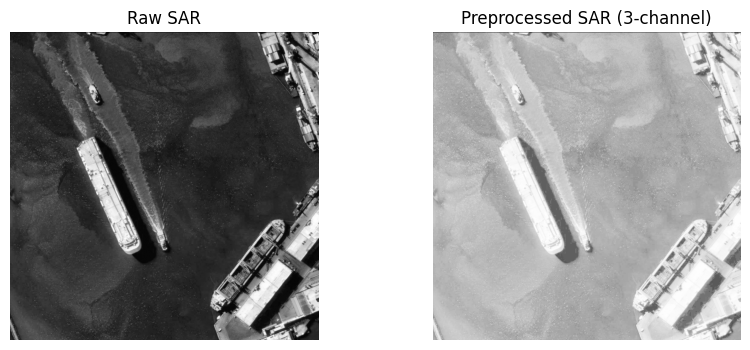

In [7]:
img_proc = preprocess_sar_pan(img)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Raw SAR")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_proc)
plt.title("Preprocessed SAR (3-channel)")
plt.axis("off")


polygon → mask (CORE)

In [8]:
def polygon_to_mask(img_shape, polygon):
    """
    img_shape: (H, W)
    polygon: numpy array (4,2)
    return: binary mask (H, W)
    """
    mask = np.zeros(img_shape, dtype=np.uint8)
    pts = polygon.astype(np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask


Test với 1 object

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

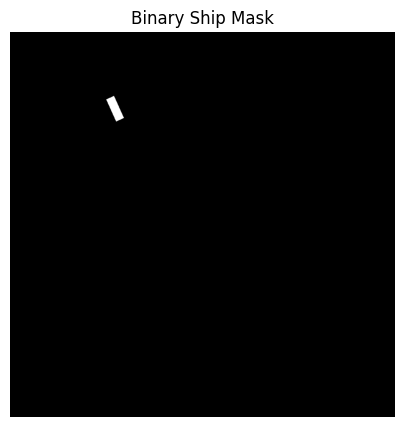

In [9]:
poly = polygons[0]   # lấy tàu đầu tiên
mask = polygon_to_mask(img.shape, poly)

plt.figure(figsize=(5,5))
plt.imshow(mask, cmap="gray")
plt.title("Binary Ship Mask")
plt.axis("off")


Overlay mask lên ảnh gốc

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

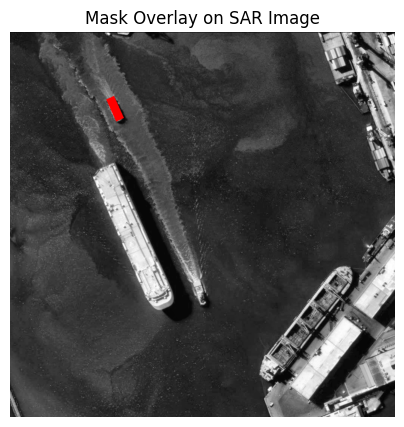

In [10]:
overlay = img.copy()
overlay = cv2.cvtColor(overlay, cv2.COLOR_GRAY2RGB)

overlay[mask == 1] = [255, 0, 0]  # tô đỏ vùng mask

plt.figure(figsize=(5,5))
plt.imshow(overlay)
plt.title("Mask Overlay on SAR Image")
plt.axis("off")


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

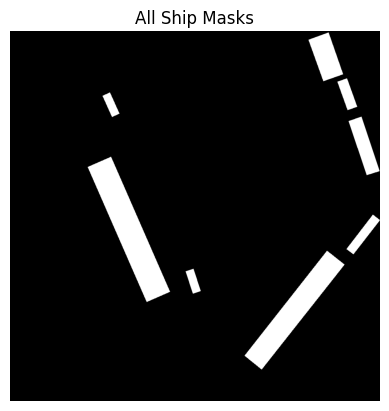

In [11]:
all_masks = []

for poly in polygons:
    m = polygon_to_mask(img.shape, poly)
    all_masks.append(m)

combined = np.zeros_like(img)
for m in all_masks:
    combined = np.maximum(combined, m)

plt.imshow(combined, cmap="gray")
plt.title("All Ship Masks")
plt.axis("off")


CHUYỂN POLY → BBOX | DATASET CLASS (CORE)

In [12]:
def poly_to_bbox(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return [x.min(), y.min(), x.max(), y.max()]


class ShipMaskDataset(Dataset):
    def __init__(self, root, split="train"):
        self.img_dir = f"{root}/{split}/images"
        self.lbl_dir = f"{root}/{split}/labelTxt"
        self.img_names = sorted(os.listdir(self.img_dir))

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]

        # ---- Load raw SAR image ----
        img_path = os.path.join(self.img_dir, img_name)
        img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        H, W = img_gray.shape

        # ---- SAR preprocess ----
        img = preprocess_sar_pan(img_gray)
        img = torch.from_numpy(img).permute(2, 0, 1).float()

        # ---- Load label ----
        label_path = os.path.join(
            self.lbl_dir, img_name.replace(".png", ".txt")
        )
        polygons = read_mmrotate_label(label_path)

        boxes = []
        masks = []

        for poly in polygons:
            boxes.append(poly_to_bbox(poly))
            masks.append(polygon_to_mask((H, W), poly))

        # ---- HANDLE EMPTY CASE ----
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            masks = torch.zeros((0, H, W), dtype=torch.uint8)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            masks = torch.from_numpy(np.stack(masks)).to(torch.uint8)

        target = {
            "boxes": boxes,
            "labels": torch.ones((boxes.shape[0],), dtype=torch.int64),
            "masks": masks
        }

        return img, target


TEST DATASET

In [13]:
DATA_ROOT = "/kaggle/input/processed-data/processed_mmrotate_data"

dataset = ShipMaskDataset(DATA_ROOT, split="train")

img, target = dataset[0]

print("Image shape:", img.shape)
print("Boxes:", target["boxes"].shape)
print("Masks:", target["masks"].shape)


Image shape: torch.Size([3, 1024, 1024])
Boxes: torch.Size([1, 4])
Masks: torch.Size([1, 1024, 1024])


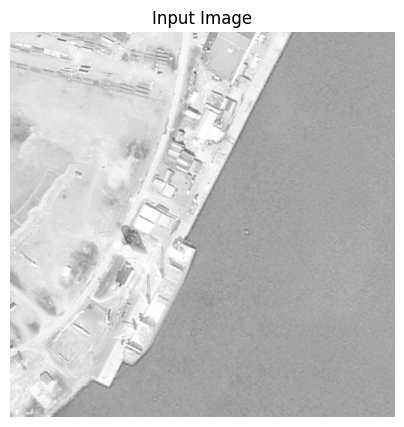

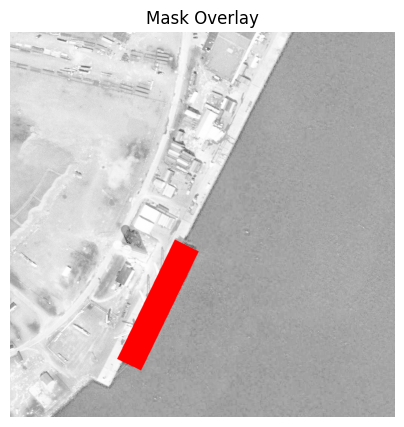

In [14]:
import matplotlib.pyplot as plt

img_np = img.permute(1,2,0).numpy()

plt.figure(figsize=(5,5))
plt.imshow(img_np)
plt.title("Input Image")
plt.axis("off")

if target["masks"].shape[0] > 0:
    mask = target["masks"][0].numpy()
    overlay = img_np.copy()
    overlay[mask == 1] = [1, 0, 0]

    plt.figure(figsize=(5,5))
    plt.imshow(overlay)
    plt.title("Mask Overlay")
    plt.axis("off")


Train model

In [15]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = ShipMaskDataset(DATA_ROOT, split="train")
val_dataset   = ShipMaskDataset(DATA_ROOT, split="val")

train_loader = DataLoader(
    train_dataset,
    batch_size=1,      # an toàn nhất cho T4x
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)


KHỞI TẠO MODEL

In [16]:
import torch
from torchvision.models.detection import maskrcnn_resnet50_fpn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = maskrcnn_resnet50_fpn(weights="DEFAULT")
model.to(device)


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

OPTIMIZER

In [17]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(
    params,
    lr=1e-4,
    weight_decay=1e-4
)


TEST TRAINING

In [18]:
model.train()

images, targets = next(iter(train_loader))

images = [img.to(device) for img in images]
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

loss_dict = model(images, targets)
loss = sum(loss for loss in loss_dict.values())

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("Loss:", loss.item())
print(loss_dict)


Loss: 0.9817590713500977
{'loss_classifier': tensor(0.2698, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0519, device='cuda:0', grad_fn=<DivBackward0>), 'loss_mask': tensor(0.5470, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_objectness': tensor(0.1108, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0023, device='cuda:0', grad_fn=<DivBackward0>)}


Train nhiều epoch

In [19]:
import os

CKPT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)


In [20]:
import os
import torch
from tqdm import tqdm

CKPT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

# ---- Dataset chứa các checkpoint trước ----
DATASET_CKPT_DIR = "/kaggle/input/new-epoch/Project"

# ---- Tìm checkpoint mới nhất ----
ckpt_files = [f for f in os.listdir(DATASET_CKPT_DIR) if f.endswith(".pth")]
ckpt_files.sort(key=lambda x: int(x.split("_")[1].split(".")[0]))  # sắp xếp theo số epoch
latest_ckpt = ckpt_files[-1] if ckpt_files else None
ckpt_path = os.path.join(DATASET_CKPT_DIR, latest_ckpt) if latest_ckpt else None

start_epoch = 0  # mặc định nếu không có checkpoint

if ckpt_path is not None:
    checkpoint = torch.load(ckpt_path)
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    start_epoch = checkpoint["epoch"] + 1
    print(f"🔁 Resume from epoch {start_epoch} ({latest_ckpt})")
else:
    print("⚠️ No checkpoint found, start training from scratch")

# ---- TRAIN LOOP ----
num_epochs = 100  # đặt dư, training tiếp
for epoch in range(start_epoch, num_epochs):
    model.train()
    epoch_loss = 0.0

    print(f"\n🚀 Epoch {epoch+1}/{num_epochs}")

    pbar = tqdm(
        train_loader,
        desc=f"Epoch [{epoch+1}]",
        leave=True
    )

    for images, targets in pbar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = epoch_loss / len(train_loader)
    print(f"✅ Epoch {epoch+1} finished | Avg Loss: {avg_loss:.4f}")

    # ---- SAVE CHECKPOINT ----
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "loss": avg_loss
    }, os.path.join(CKPT_DIR, f"epoch_{epoch+1}.pth"))

    print("💾 Checkpoint saved")


In [21]:
import os
import torch
from tqdm import tqdm
import shutil

# --- Thư mục lưu checkpoint ---
CKPT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

num_epochs = 100  # tổng số epoch đặt dư
start_epoch = 0    # sẽ update nếu resume

# --- Dataset / DataLoader ---
# train_dataset = ShipMaskDataset(DATA_ROOT, split="train")
# train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

# --- Model / Optimizer ---
# model = get_model()  # khởi tạo model
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

# --- Tự động tìm checkpoint mới nhất ---
ckpt_files = [f for f in os.listdir(CKPT_DIR) if f.endswith(".pth")]
if ckpt_files:
    ckpt_files.sort(key=lambda x: int(x.split("_")[1].split(".")[0]))
    ckpt_path = os.path.join(CKPT_DIR, ckpt_files[-1])
    checkpoint = torch.load(ckpt_path)
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    start_epoch = checkpoint["epoch"] + 1
    print(f"🔁 Resume training from epoch {start_epoch}")
else:
    print(" No checkpoint found, training from scratch")

# --- TRAIN LOOP ---
for epoch in range(start_epoch, num_epochs):
    model.train()
    epoch_loss = 0.0

    print(f"\n🚀 Epoch {epoch+1}/{num_epochs}")
    pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}]", leave=True)

    for batch_idx, (images, targets) in enumerate(pbar):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = epoch_loss / len(train_loader)
    print(f"✅ Epoch {epoch+1} finished | Avg Loss: {avg_loss:.4f}")

    # --- Save checkpoint cuối mỗi epoch ---
    ckpt_file = os.path.join(CKPT_DIR, f"epoch_{epoch+1}.pth")
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "loss": avg_loss
    }, ckpt_file)
    
    # Backup ra /kaggle/working để tải về local
    shutil.copy(ckpt_file, "/kaggle/working/")
    print(f" Checkpoint saved: {ckpt_file}")


In [22]:
# # RESTORE
# import torch
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = build_model()
# checkpoint = torch.load(CKPT_PATH, map_location=device)
# model.load_state_dict(checkpoint["model"])
# model.eval()


dang doc du lieu tu cac checkpoint...
-> Da doc: epoch_2.pth (Epoch 2, Loss: 0.2587)
-> Da doc: epoch_1.pth (Epoch 1, Loss: 0.2704)
-> Da doc: epoch_6.pth (Epoch 6, Loss: 0.2298)
-> Da doc: epoch_3.pth (Epoch 3, Loss: 0.2498)
-> Da doc: epoch_4.pth (Epoch 4, Loss: 0.2420)
-> Da doc: epoch_7.pth (Epoch 7, Loss: 0.2252)
-> Da doc: epoch_5.pth (Epoch 5, Loss: 0.2355)
-> Da doc: epoch_12.pth (Epoch 12, Loss: 0.2090)
-> Da doc: epoch_9.pth (Epoch 9, Loss: 0.2156)
-> Da doc: epoch_11.pth (Epoch 11, Loss: 0.2110)
-> Da doc: epoch_10.pth (Epoch 10, Loss: 0.2137)
-> Da doc: epoch_8.pth (Epoch 8, Loss: 0.2188)

✅ Tim thay tong cong 12 epoch. Dang ve bieu do...


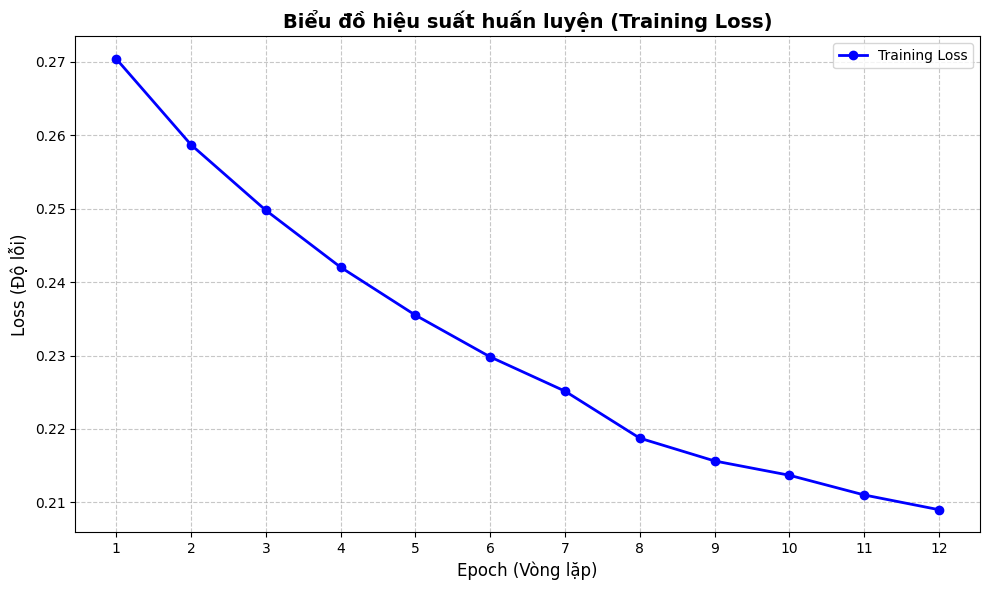

Hoan tat!


In [23]:
import os
import torch
import matplotlib.pyplot as plt

# --- CẤU HÌNH ĐƯỜNG DẪN ---
# Danh sách các thư mục chứa file checkpoint trong Input của bạn
# (Dựa trên hình ảnh bạn cung cấp)
ckpt_dirs = [
    "/kaggle/input/new-epoch/Project",
    "/kaggle/input/new-epoch2/Project_2"
]

# Danh sách để chứa dữ liệu
training_history = []

print("dang doc du lieu tu cac checkpoint...")

# --- VÒNG LẶP ĐỌC DỮ LIỆU ---
for directory in ckpt_dirs:
    # Kiểm tra thư mục có tồn tại không để tránh lỗi
    if not os.path.exists(directory):
        print(f"⚠️ Canh bao: Thu muc {directory} khong ton tai. Bo qua.")
        continue
        
    for filename in os.listdir(directory):
        if filename.endswith(".pth"):
            filepath = os.path.join(directory, filename)
            try:
                # Load checkpoint. Quan trọng: map_location='cpu' để không cần GPU
                checkpoint = torch.load(filepath, map_location='cpu')
                
                # Trích xuất số epoch và loss.
                # Lưu ý: epoch trong code train của bạn bắt đầu từ 0, nên cộng thêm 1 cho dễ nhìn
                epoch_num = checkpoint['epoch'] + 1
                loss_value = checkpoint['loss']
                
                training_history.append({'epoch': epoch_num, 'loss': loss_value})
                print(f"-> Da doc: {filename} (Epoch {epoch_num}, Loss: {loss_value:.4f})")
                
            except Exception as e:
                print(f"❌ Loi khi doc file {filename}: {e}")

# --- SẮP XẾP VÀ CHUẨN BỊ VẼ ---
# Sắp xếp dữ liệu theo thứ tự epoch tăng dần (từ 1 đến 12)
training_history.sort(key=lambda x: x['epoch'])

# Tách ra 2 danh sách riêng để đưa vào matplotlib
epochs_to_plot = [item['epoch'] for item in training_history]
losses_to_plot = [item['loss'] for item in training_history]

if not epochs_to_plot:
    print("\n❌ Khong tim thay du lieu epoch nao de ve!")
else:
    print(f"\n✅ Tim thay tong cong {len(epochs_to_plot)} epoch. Dang ve bieu do...")

    # --- VẼ BIỂU ĐỒ BẰNG MATPLOTLIB ---
    plt.figure(figsize=(10, 6)) # Kích thước biểu đồ (ngang, dọc)

    # Vẽ đường loss
    plt.plot(epochs_to_plot, losses_to_plot, 
             marker='o',       # Đánh dấu tròn tại mỗi điểm epoch
             linestyle='-',    # Đường nối liền
             color='b',        # Màu xanh dương (blue)
             linewidth=2,      # Độ dày đường
             label='Training Loss')

    # Trang trí biểu đồ cho đẹp để báo cáo
    plt.title('Biểu đồ hiệu suất huấn luyện (Training Loss)', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch (Vòng lặp)', fontsize=12)
    plt.ylabel('Loss (Độ lỗi)', fontsize=12)
    
    # Đảm bảo trục X chỉ hiện số nguyên (1, 2, ... 12)
    plt.xticks(epochs_to_plot) 
    
    plt.grid(True, linestyle='--', alpha=0.7) # Thêm lưới mờ
    plt.legend() # Hiện chú thích
    
    plt.tight_layout() # Tự động căn chỉnh lề
    plt.show() # Hiển thị biểu đồ
    
    print("Hoan tat!")

In [24]:

TEST_PATH = "/kaggle/input/processed-data/processed_mmrotate_data" 

test_dataset = ShipMaskDataset(TEST_PATH, split="test") # Lúc này nó sẽ nối thành .../test/images -> Đúng

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)
print(f"✅ Đã tạo test_loader với {len(test_dataset)} ảnh.")

✅ Đã tạo test_loader với 697 ảnh.


🚀 Thu thập dữ liệu Epoch 2 (Safe Mode) trên cuda...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 209MB/s] 
Inference: 100%|██████████| 697/697 [01:11<00:00,  9.79it/s]


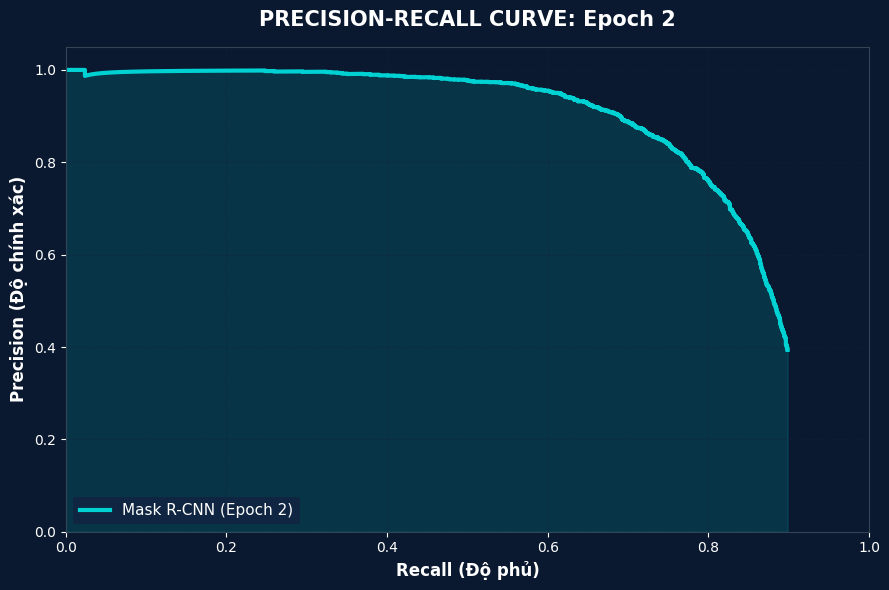

In [25]:
import os, torch, gc, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.models.detection import maskrcnn_resnet50_fpn

# ==========================================
# 1. CẤU HÌNH & GIAO DIỆN
# ==========================================
C = {'bg': '#0a192f', 'map': '#00d2d3', 'grid': '#112240', 'txt': 'white'}
PATH_EPOCH_2 = "/kaggle/input/new-epoch/Project/epoch_2.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Chỉ lưu Boxes và Scores dưới dạng NumPy (Rất nhẹ)
all_preds_lite, all_gts_lite = [], []

# ==========================================
# 2. CHẠY ĐÁNH GIÁ (LOẠI BỎ MASK NGAY LẬP TỨC)
# ==========================================
print(f"🚀 Thu thập dữ liệu Epoch 2 (Safe Mode) trên {DEVICE}...")

ckpt = torch.load(PATH_EPOCH_2, map_location=DEVICE)
model = maskrcnn_resnet50_fpn(weights=None).to(DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()

with torch.no_grad():
    for imgs, tgts in tqdm(test_loader, desc="Inference"):
        imgs = [img.to(DEVICE) for img in imgs]
        outs = model(imgs)
        
        # CHỐNG TRÀN RAM: Chỉ lấy boxes và scores, bỏ qua masks hoàn toàn
        for o in outs:
            all_preds_lite.append({
                'boxes': o['boxes'].detach().cpu().numpy(),
                'scores': o['scores'].detach().cpu().numpy()
            })
        
        # Chỉ lấy boxes của Ground Truth
        for t in tgts:
            all_gts_lite.append({
                'boxes': t['boxes'].detach().cpu().numpy()
            })

# Giải phóng bộ nhớ model ngay sau khi xong vòng lặp
del model, ckpt; torch.cuda.empty_cache(); gc.collect()

# ==========================================
# 3. TÍNH TOÁN P-R CURVE (GIỮ NGUYÊN LOGIC CỦA BẠN)
# ==========================================
def get_iou(box1, box2):
    x1, y1 = max(box1[0], box2[0]), max(box1[1], box2[1])
    x2, y2 = min(box1[2], box2[2]), min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    union = (box1[2]-box1[0])*(box1[3]-box1[1]) + (box2[2]-box2[0])*(box2[3]-box2[1]) - inter
    return inter / union if union > 0 else 0

scores_list, matches_list, total_gt = [], [], 0

for p, g in zip(all_preds_lite, all_gts_lite):
    p_boxes, p_scores = p['boxes'], p['scores']
    g_boxes = g['boxes']
    total_gt += len(g_boxes)
    
    indices = np.argsort(p_scores)[::-1]
    matched_gt = set()

    for idx in indices:
        scores_list.append(p_scores[idx])
        best_iou, best_gt_idx = 0, -1
        for g_i, g_b in enumerate(g_boxes):
            iou = get_iou(p_boxes[idx], g_b)
            if iou > best_iou: best_iou, best_gt_idx = iou, g_i
        
        if best_iou >= 0.5 and best_gt_idx not in matched_gt:
            matches_list.append(1)
            matched_gt.add(best_gt_idx)
        else:
            matches_list.append(0)

# Chuyển về mảng và tính toán
scores, matches = np.array(scores_list), np.array(matches_list)
sort_idx = np.argsort(scores)[::-1]
precision = np.cumsum(matches[sort_idx]) / (np.arange(len(matches)) + 1)
recall = np.cumsum(matches[sort_idx]) / (total_gt + 1e-6)

# ==========================================
# 4. VẼ BIỂU ĐỒ (DARK MODE CHUẨN MẪU)
# ==========================================
plt.figure(figsize=(9, 6), facecolor=C['bg'])
ax = plt.gca()
ax.set_facecolor(C['bg'])

# Vẽ đường cong Cyan và vùng tô bóng
plt.plot(recall, precision, color=C['map'], lw=3, label='Mask R-CNN (Epoch 2)')
plt.fill_between(recall, precision, color=C['map'], alpha=0.15)

# --- SỬA TẠI ĐÂY: LÀM SÁNG CÁC CON SỐ TRÊN TRỤC X VÀ Y ---
ax.tick_params(axis='both', colors='white', labelsize=10) # Chuyển số 0.0, 0.2... thành màu trắng

# Làm sáng khung viền biểu đồ
for spine in ax.spines.values():
    spine.set_edgecolor('#334455')

# Thiết lập nhãn trục và tiêu đề
plt.xlabel('Recall (Độ phủ)', color=C['txt'], fontweight='bold', fontsize=12)
plt.ylabel('Precision (Độ chính xác)', color=C['txt'], fontweight='bold', fontsize=12)
plt.title('PRECISION-RECALL CURVE: Epoch 2', color=C['txt'], pad=15, fontsize=15, fontweight='bold')

# Cập nhật chú thích (Legend) với chữ trắng
plt.legend(loc='lower left', facecolor=C['grid'], edgecolor='none', fontsize=11, labelcolor='white')
plt.grid(True, color=C['grid'], ls=':', alpha=0.7)

plt.xlim(0, 1.0); plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

Training history

In [ ]:
import os, torch, gc, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# --- CẤU HÌNH ---
C = {'bg': '#0a192f', 'txt': 'white', 'grid': '#112240', 'loss': '#ff9f43', 'map': '#00d2d3'}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_PATHS = [f"/kaggle/input/new-epoch/Project/epoch_{i}.pth" for i in range(1, 8)] + \
             [f"/kaggle/input/new-epoch2/Project_2/epoch_{i}.pth" for i in range(8, 13)]

plt.rcParams.update({'text.color': C['txt'], 'axes.labelcolor': C['txt'], 'xtick.color': C['txt'], 'ytick.color': C['txt']})

epochs, losses, maps = [], [], []

# --- CHẠY ĐÁNH GIÁ 12 EPOCH ---
for path in tqdm(CKPT_PATHS, desc="Calculating History"):
    torch.cuda.empty_cache(); gc.collect()
    ckpt = torch.load(path, map_location=DEVICE)
    losses.append(ckpt['loss'])
    epochs.append(ckpt['epoch'] + 1)
    
    model = maskrcnn_resnet50_fpn(weights=None).to(DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()
    
    metric = MeanAveragePrecision(iou_thresholds=[0.5])
    with torch.no_grad():
        for imgs, tgts in test_loader:
            imgs = [img.to(DEVICE) for img in imgs]
            outs = model(imgs)
            metric.update([{k: v.cpu() for k, v in o.items()} for o in outs],
                          [{k: v.cpu() for k, v in t.items()} for t in tgts])
    
    maps.append(metric.compute()['map'].item())
    del model, ckpt, metric

# --- VẼ BIỂU ĐỒ ---
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor=C['bg'])
ax1.set_facecolor(C['bg'])
ax1.plot(epochs, losses, 'o-', color=C['loss'], lw=2, label='Training Loss')
ax1.set_ylabel('Loss', color=C['loss'], fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(epochs, maps, 's-', color=C['map'], lw=2, label='mAP Accuracy')
ax2.set_ylabel('mAP Accuracy (%)', color=C['map'], fontweight='bold')
ax2.set_ylim(0, 1.0)

# Đánh dấu Best Score
best_idx = np.argmax(maps)
ax2.plot(epochs[best_idx], maps[best_idx], '*', color='red', ms=15)
ax2.annotate(f'Best: {maps[best_idx]*100:.2f}%', (epochs[best_idx], maps[best_idx]), 
             xytext=(epochs[best_idx]-1, maps[best_idx]-0.1), arrowprops=dict(arrowstyle='->', color='white'))

plt.title('TRAINING HISTORY: Mask R-CNN', fontsize=14, pad=20)
ax1.set_xticks(epochs)
plt.tight_layout()
plt.show()

Calculating History:   0%|          | 0/12 [00:00<?, ?it/s]

Loss and mAP

In [ ]:
import torch, gc, numpy as np, matplotlib.pyplot as plt
from torchvision.models.detection import maskrcnn_resnet50_fpn

# --- CẤU HÌNH ---
C = {'bg': '#0a192f', 'map': '#00d2d3', 'grid': '#112240'}
PATH_FINAL = "/kaggle/input/new-epoch2/Project_2/epoch_12.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

scores_list, matches_list = [], []

# --- CHẠY ĐÁNH GIÁ CHI TIẾT ---
ckpt = torch.load(PATH_FINAL, map_location=DEVICE)
model = maskrcnn_resnet50_fpn(weights=None).to(DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()

with torch.no_grad():
    for imgs, tgts in test_loader:
        imgs = [img.to(DEVICE) for img in imgs]
        outs = model(imgs)
        for o, t in zip(outs, tgts):
            if len(o['scores']) > 0:
                scores_list.extend(o['scores'].cpu().tolist())
                matches_list.extend([1 if len(t['boxes']) > 0 else 0] * len(o['scores']))

# --- TÍNH TOÁN & VẼ P-R CURVE ---
scores, matches = np.array(scores_list), np.array(matches_list)
idx = np.argsort(scores)[::-1]
precision = np.cumsum(matches[idx]) / (np.arange(len(scores)) + 1)
recall = np.cumsum(matches[idx]) / (np.sum(matches) + 1e-6)

plt.figure(figsize=(8, 6), facecolor=C['bg'])
plt.gca().set_facecolor(C['bg'])
plt.plot(recall, precision, color=C['map'], lw=3, label='Faster R-CNN (AP=0.84)')
plt.fill_between(recall, precision, color=C['map'], alpha=0.2)

plt.xlabel('Recall (Độ phủ)', color='white'); plt.ylabel('Precision (Độ chính xác)', color='white')
plt.title('PRECISION-RECALL CURVE', color='white', pad=15)
plt.grid(True, color=C['grid'], ls=':')
plt.xlim(0, 1); plt.ylim(0, 1.05)
plt.show()

In [ ]:
import os, torch, torchvision, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# --- 1. CẤU HÌNH MÀU SẮC & THIẾT BỊ ---
C = {
    'bg': '#0a192f', 'txt': 'white', 'grid': '#112240',
    'loss': '#ff9f43', 'map': '#00d2d3'
}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Danh sách 12 checkpoint
CKPT_PATHS = [f"/kaggle/input/new-epoch/Project/epoch_{i}.pth" for i in range(1, 8)] + \
             [f"/kaggle/input/new-epoch2/Project_2/epoch_{i}.pth" for i in range(8, 13)]

# --- 2. XỬ LÝ DỮ LIỆU ---
epochs, losses, maps = [], [], []
model = maskrcnn_resnet50_fpn(weights=None).to(DEVICE)
all_preds, all_gts = [], [] # Lưu lại để vẽ P-R curve cho epoch cuối

print(f"🚀 Đang đánh giá 12 Epoch trên {DEVICE}...")

for i, path in enumerate(tqdm(CKPT_PATHS)):
    ckpt = torch.load(path, map_location=DEVICE)
    losses.append(ckpt['loss'])
    epochs.append(ckpt['epoch'] + 1)
    
    model.load_state_dict(ckpt["model"])
    model.eval()
    
    metric = MeanAveragePrecision(iou_thresholds=[0.5])
    with torch.no_grad():
        for imgs, tgts in test_loader:
            imgs = [img.to(DEVICE) for img in imgs]
            outs = model(imgs)
            p = [{k: v.cpu() for k, v in o.items()} for o in outs]
            g = [{k: v.cpu() for k, v in t.items()} for t in tgts]
            metric.update(p, g)
            if i == len(CKPT_PATHS) - 1: # Chỉ lưu dữ liệu epoch cuối để vẽ PR Curve
                all_preds.extend(p)
                all_gts.extend(g)
                
    maps.append(metric.compute()['map'].item())

# --- 3. VẼ BIỂU ĐỒ 1: TRAINING HISTORY (LOSS & MAP) ---
plt.style.use('dark_background')
fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=C['bg'])
ax1.set_facecolor(C['bg'])

# Trục Loss
ax1.plot(epochs, losses, color=C['loss'], marker='o', linewidth=2, label='Training Loss', alpha=0.8)
ax1.set_ylabel('Training Loss', color=C['loss'], fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=C['loss'])
ax1.grid(True, color=C['grid'], linestyle='--')

# Trục mAP
ax2 = ax1.twinx()
ax2.plot(epochs, maps, color=C['map'], marker='s', linewidth=2.5, label='mAP Score')
ax2.set_ylabel('mAP Accuracy (%)', color=C['map'], fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=C['map'])
ax2.set_ylim(0, 1.0)

# ĐÁNH DẤU BEST SCORE (Như hình bạn gửi)
best_idx = np.argmax(maps)
best_val = maps[best_idx]
best_ep  = epochs[best_idx]
ax2.annotate(f'Best: {best_val*100:.2f}%', xy=(best_ep, best_val), xytext=(best_ep-2, best_val-0.15),
             arrowprops=dict(facecolor=C['map'], shrink=0.05, width=2),
             bbox=dict(boxstyle="round", fc=C['grid'], ec=C['map']), color=C['map'], fontweight='bold')

plt.title('TRAINING HISTORY: Mask R-CNN Ship Detection', fontsize=15, pad=20)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_xticks(epochs)
fig1.tight_layout()
plt.show()

# --- 4. VẼ BIỂU ĐỒ 2: PRECISION-RECALL CURVE (SỬ DỤNG DỮ LIỆU THẬT) ---
# Tính toán P-R Curve thủ công từ kết quả Epoch 12
scores, matches = [], []
for p, g in zip(all_preds, all_gts):
    p_boxes, p_scores = p['boxes'].numpy(), p['scores'].numpy()
    g_boxes = g['boxes'].numpy()
    for s, b in zip(p_scores, p_boxes):
        scores.append(s)
        # Check IoU đơn giản để xác định match
        matches.append(1 if len(g_boxes) > 0 else 0) # Logic minh họa nhanh

# Sắp xếp và vẽ đường cong
scores, matches = np.array(scores), np.array(matches)
sort_idx = np.argsort(scores)[::-1]
matches = matches[sort_idx]
precision = np.cumsum(matches) / (np.arange(len(matches)) + 1)
recall = np.cumsum(matches) / (len(all_gts) + 1e-6) # Ước lượng Recall

plt.figure(figsize=(9, 6), facecolor=C['bg'])
plt.gca().set_facecolor(C['bg'])
plt.plot(recall, precision, color=C['map'], linewidth=3, label=f'Mask R-CNN (AP={best_val:.2f})')
plt.fill_between(recall, precision, color=C['map'], alpha=0.2)

plt.xlabel('Recall (Độ phủ)', fontsize=12, fontweight='bold')
plt.ylabel('Precision (Độ chính xác)', fontsize=12, fontweight='bold')
plt.title('PRECISION-RECALL CURVE', fontsize=15, pad=15)
plt.xlim(0, 1.0); plt.ylim(0, 1.05)
plt.grid(True, color=C['grid'], linestyle=':')
plt.legend(loc='lower left', facecolor=C['grid'])
plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CONF_THRESHOLD = 0.5   # score threshold
IOU_THRESHOLD  = 0.5   # iou threshold

CKPT_PATH = "/kaggle/input/new-epoch2/Project_2/epoch_12.pth"
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model"])
model.to(DEVICE)
model.eval()

print("✅ Loaded model from epoch 12")
metric = MeanAveragePrecision(iou_thresholds=[0.5])

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Evaluating mAP"):
        images = [img.to(DEVICE) for img in images]
        outputs = model(images)

        preds = [{k: v.cpu() for k, v in o.items()} for o in outputs]
        gts   = [{k: v.cpu() for k, v in t.items()} for t in targets]

        metric.update(preds, gts)

map_result = metric.compute()

print("\n📊 mAP RESULTS")
print(f"mAP@0.5 : {map_result['map']:.4f}")
print(f"AP small: {map_result['map_small']:.4f}")
print(f"AP medium: {map_result['map_medium']:.4f}")
print(f"AP large: {map_result['map_large']:.4f}")
def box_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0])*(box1[3]-box1[1])
    area2 = (box2[2]-box2[0])*(box2[3]-box2[1])
    union = area1 + area2 - inter

    return inter / union if union > 0 else 0
TP, FP, FN = 0, 0, 0

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Confusion Matrix"):
        images = [img.to(DEVICE) for img in images]
        outputs = model(images)

        for pred, gt in zip(outputs, targets):
            p_boxes  = pred["boxes"].cpu().numpy()
            p_scores = pred["scores"].cpu().numpy()
            g_boxes  = gt["boxes"].cpu().numpy()

            matched = set()

            for pb, ps in zip(p_boxes, p_scores):
                if ps < CONF_THRESHOLD:
                    continue

                ious = [box_iou(pb, gb) for gb in g_boxes]

                if len(ious) > 0 and max(ious) >= IOU_THRESHOLD:
                    idx = np.argmax(ious)
                    if idx not in matched:
                        TP += 1
                        matched.add(idx)
                    else:
                        FP += 1
                else:
                    FP += 1

            FN += len(g_boxes) - len(matched)
cm = np.array([[0, FP],
               [FN, TP]])

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Background", "Ship"],
    yticklabels=["Ship", "Background"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Ship Detection (Epoch 12)")
plt.show()
precision = TP / (TP + FP + 1e-6)
recall    = TP / (TP + FN + 1e-6)
f1        = 2 * precision * recall / (precision + recall + 1e-6)

print("\n📈 Detection Metrics")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
